Cell 1: load the data

In [1]:
import pandas as pd, numpy as np, json, joblib
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay,
                             classification_report)

train = pd.read_csv("../data/processed/train.csv")
test = pd.read_csv("../data/processed/test.csv")

X_train, y_train = train.drop(columns="NSP"), train["NSP"]
X_test, y_test = test.drop(columns="NSP"), test["NSP"]

scaler = joblib.load("../data/processed/scaler.pkl")
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

top10 = json.load(open("../data/processed/top10_features.json"))

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Top 10:", top10)

Train: (1691, 21)  Test: (423, 21)
Top 10: ['DP', 'ALTV', 'ASTV', 'Mean', 'Mode', 'Median', 'AC', 'Variance', 'LB', 'MSTV']


Cell 2: evaluation function and the baseline.

              precision    recall  f1-score   support

      Normal       0.93      0.96      0.95       330
     Suspect       0.68      0.59      0.63        58
Pathological       0.90      0.77      0.83        35

    accuracy                           0.90       423
   macro avg       0.84      0.77      0.80       423
weighted avg       0.89      0.90      0.89       423



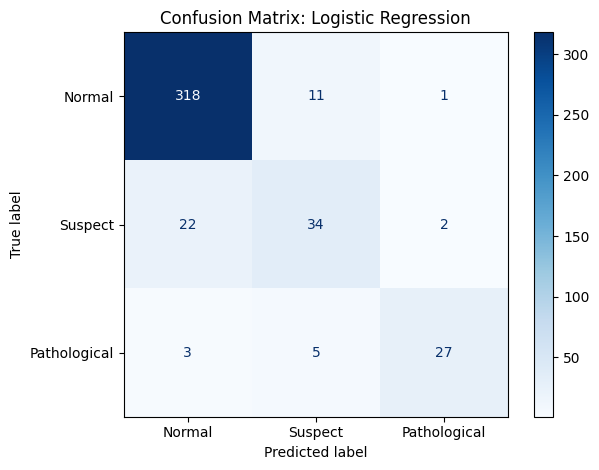

In [2]:
from sklearn.linear_model import LogisticRegression

results = []
class_names = ["Normal", "Suspect", "Pathological"]

def evaluate(name, y_true, y_pred):
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="macro"),
        "Recall": recall_score(y_true, y_pred, average="macro"),
        "Macro F1": f1_score(y_true, y_pred, average="macro"),
    })
    print(classification_report(y_true, y_pred, target_names=class_names))
    ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred),
                           display_labels=class_names).plot(cmap="Blues", values_format="d")
    plt.title(f"Confusion Matrix: {name}")
    plt.tight_layout()
    plt.savefig(f"../results/figures/cm_{name.replace(' ', '_')}.png", dpi=150)
    plt.show()

lr = LogisticRegression(max_iter=2000, random_state=42)
lr.fit(X_train_s, y_train)
evaluate("Logistic Regression", y_test, lr.predict(X_test_s))

Step P2-2: Decision Tree, Random Forest and XGBoost

Cell 3: Decision Tree

              precision    recall  f1-score   support

      Normal       0.95      0.96      0.96       330
     Suspect       0.82      0.71      0.76        58
Pathological       0.82      0.94      0.88        35

    accuracy                           0.93       423
   macro avg       0.87      0.87      0.87       423
weighted avg       0.93      0.93      0.93       423



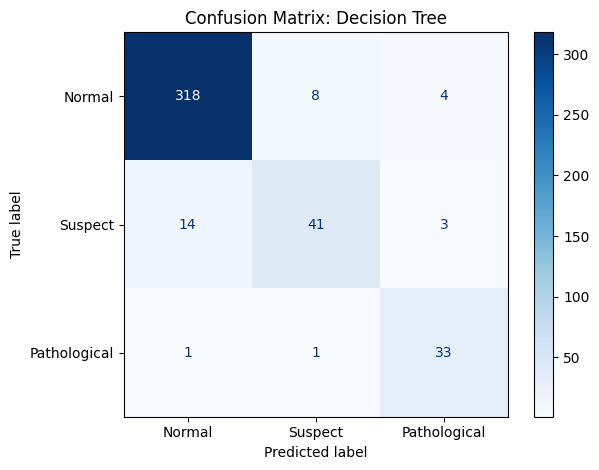

In [3]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
evaluate("Decision Tree", y_test, dt.predict(X_test))

Cell 4: Random Forest

              precision    recall  f1-score   support

      Normal       0.95      0.99      0.97       330
     Suspect       0.91      0.71      0.80        58
Pathological       0.97      0.91      0.94        35

    accuracy                           0.95       423
   macro avg       0.94      0.87      0.90       423
weighted avg       0.95      0.95      0.95       423



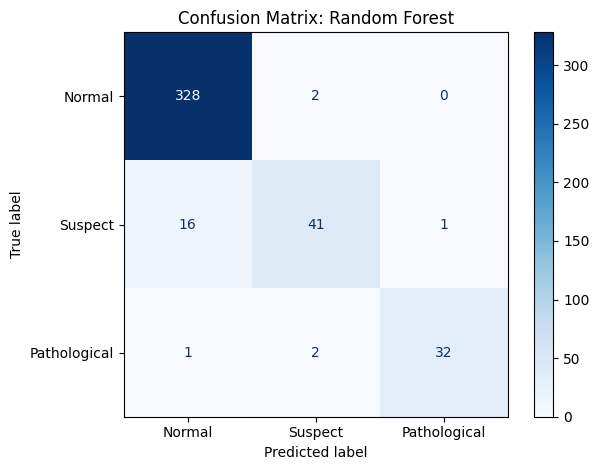

In [4]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
evaluate("Random Forest", y_test, rf.predict(X_test))

Cell 5: XGBoost

              precision    recall  f1-score   support

      Normal       0.96      0.99      0.97       330
     Suspect       0.93      0.74      0.83        58
Pathological       0.97      0.94      0.96        35

    accuracy                           0.96       423
   macro avg       0.95      0.89      0.92       423
weighted avg       0.95      0.96      0.95       423



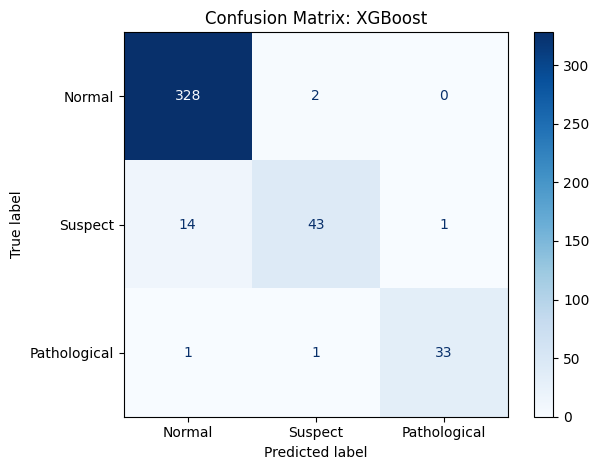

In [10]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=200, random_state=42, eval_metric="mlogloss")
xgb.fit(X_train, y_train - 1)
xgb_pred = xgb.predict(X_test) + 1
evaluate("XGBoost", y_test, xgb_pred)

Cell 6: comparison table

In [6]:
comparison = pd.DataFrame(results).round(4).sort_values("Macro F1", ascending=False)
print(comparison.to_string(index=False))
comparison.to_csv("../results/model_results.csv", index=False)

              Model  Accuracy  Precision  Recall  Macro F1
            XGBoost    0.9551     0.9539  0.8927    0.9194
      Random Forest    0.9480     0.9438  0.8717    0.9030
      Decision Tree    0.9267     0.8667  0.8711    0.8662
Logistic Regression    0.8960     0.8357  0.7738    0.8018


Step P2-3: Tune the best model (XGBoost)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
Best CV macro F1: 0.9095
              precision    recall  f1-score   support

      Normal       0.95      0.99      0.97       330
     Suspect       0.93      0.74      0.83        58
Pathological       1.00      0.94      0.97        35

    accuracy                           0.96       423
   macro avg       0.96      0.89      0.92       423
weighted avg       0.95      0.96      0.95       423



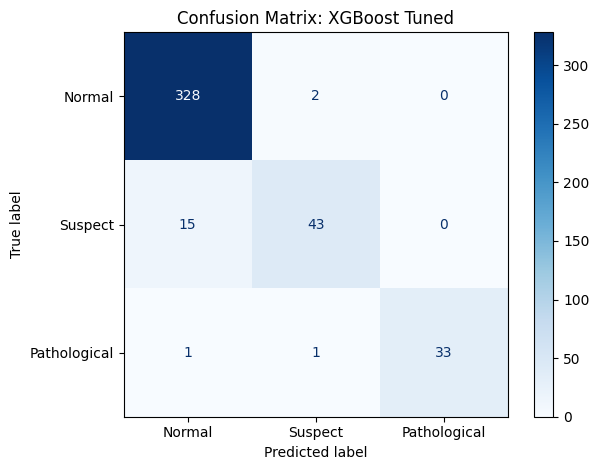

In [7]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "min_child_weight": [1, 3, 5],
}

search = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric="mlogloss"),
    param_distributions=param_dist,
    n_iter=30,
    scoring="f1_macro",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    random_state=42,
    n_jobs=-1,
    verbose=1,
)
search.fit(X_train, y_train - 1)

print("Best params:", search.best_params_)
print("Best CV macro F1:", round(search.best_score_, 4))

best_xgb = search.best_estimator_
evaluate("XGBoost Tuned", y_test, best_xgb.predict(X_test) + 1)

Step P2-4: Feature-selection experiment

In [8]:
from sklearn.base import clone
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
all_cols = list(X_train.columns)

rows = []
for label, cols in [("A: All 21 features", all_cols), ("B: Top 10 features", top10)]:
    m = clone(best_xgb)
    cv_scores = cross_val_score(m, X_train[cols], y_train - 1, cv=cv, scoring="f1_macro")
    m.fit(X_train[cols], y_train - 1)
    pred = m.predict(X_test[cols]) + 1
    rows.append({
        "Experiment": label,
        "Features": len(cols),
        "CV Macro F1": round(cv_scores.mean(), 4),
        "CV Std": round(cv_scores.std(), 4),
        "Test Accuracy": round(accuracy_score(y_test, pred), 4),
        "Test Macro F1": round(f1_score(y_test, pred, average="macro"), 4),
    })

fs_results = pd.DataFrame(rows)
print(fs_results.to_string(index=False))
fs_results.to_csv("../results/feature_selection_experiment.csv", index=False)

        Experiment  Features  CV Macro F1  CV Std  Test Accuracy  Test Macro F1
A: All 21 features        21       0.9135  0.0170         0.9551         0.9236
B: Top 10 features        10       0.9002  0.0228         0.9551         0.9222


Step P2-5: Finalize (save the model, importances, final table)

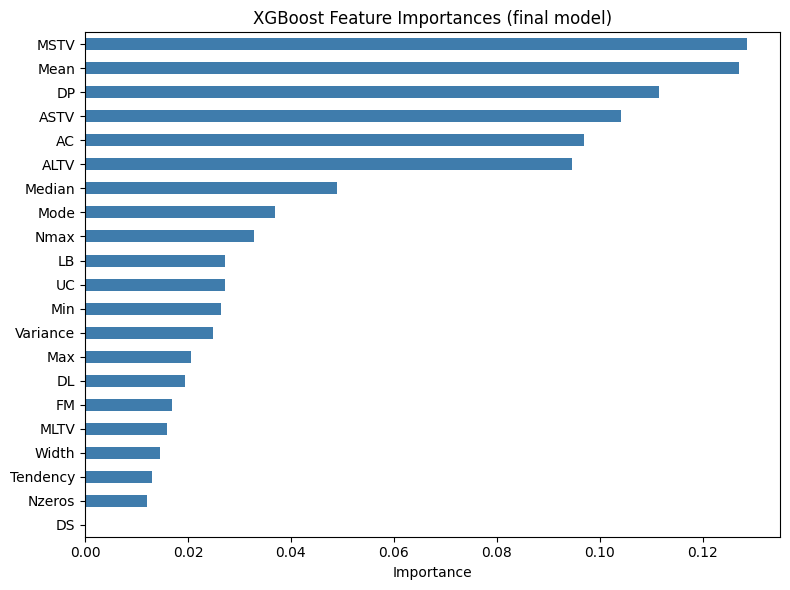

MSTV      0.1286
Mean      0.1270
DP        0.1115
ASTV      0.1042
AC        0.0970
ALTV      0.0947
Median    0.0490
Mode      0.0370
Nmax      0.0328
LB        0.0272
dtype: float32

               Model  Accuracy  Precision  Recall  Macro F1
      XGBoost Tuned    0.9551     0.9628  0.8927    0.9236
            XGBoost    0.9551     0.9539  0.8927    0.9194
      Random Forest    0.9480     0.9438  0.8717    0.9030
      Decision Tree    0.9267     0.8667  0.8711    0.8662
Logistic Regression    0.8960     0.8357  0.7738    0.8018


In [9]:
# 1. Save the final model
joblib.dump(best_xgb, "../results/final_model_xgboost.pkl")

# 2. Feature importances of the final model
imp = pd.Series(best_xgb.feature_importances_, index=X_train.columns).sort_values()
plt.figure(figsize=(8, 6))
imp.plot(kind="barh", color="#3f7cac")
plt.title("XGBoost Feature Importances (final model)")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("../results/figures/07_feature_importances.png", dpi=150)
plt.show()
print(imp.sort_values(ascending=False).head(10).round(4))

# 3. Final results table (all models incl. tuned)
final_table = pd.DataFrame(results).round(4).sort_values("Macro F1", ascending=False)
final_table.to_csv("../results/model_results.csv", index=False)
print("\n", final_table.to_string(index=False))